In [1]:
import json
from typing import Dict

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from thesis.eta.config import OUTPUTS_DIR

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# ETA Experiments Analysis

This notebook analyzes the results from various ETA prediction experiments, comparing different preprocessing techniques against the baseline performance.


In [2]:
def load_experiment_results() -> Dict[str, Dict[str, Dict]]:
    """Load all experiment results from the outputs directory."""
    results = {}

    # Get all experiment directories
    experiment_dirs = [d for d in OUTPUTS_DIR.iterdir() if d.is_dir()]

    for exp_dir in experiment_dirs:
        exp_name = exp_dir.name
        results[exp_name] = {}

        # Look for results directory
        results_dir = exp_dir / "results"
        if results_dir.exists():
            # Load all JSON files in the results directory
            for json_file in results_dir.glob("*.json"):
                scenario_name = json_file.stem
                with open(json_file, "r") as f:
                    results[exp_name][scenario_name] = json.load(f)

    return results


# Load all results
all_results = load_experiment_results()

# Display available experiments and scenarios
print("Available experiments:")
for exp_name in all_results:
    print(f"\n{exp_name}:")
    for scenario in all_results[exp_name]:
        print(f"  - {scenario}")


Available experiments:

baseline:
  - base-closure
  - base-rain
  - base
  - closure
  - rain

box_cox_transform_target:
  - base-closure
  - base-rain
  - base
  - closure
  - rain

log_transform_features:
  - base-closure
  - base-rain
  - base
  - closure
  - rain

log_transform_target:
  - base-closure
  - base-rain
  - base
  - closure
  - rain

playground:
  - base

quantile_normal_transform_target:
  - base-closure
  - base-rain
  - base
  - closure
  - rain

standard_scale_features:
  - base-closure
  - base-rain
  - base
  - closure
  - rain


In [3]:
def results_to_dataframe(results: Dict[str, Dict[str, Dict]]) -> pd.DataFrame:
    """Convert nested results dictionary to a pandas DataFrame."""
    rows = []

    for experiment, scenarios in results.items():
        for scenario, models in scenarios.items():
            for model, metrics in models.items():
                row = {
                    "experiment": experiment,
                    "scenario": scenario,
                    "model": model,
                    **metrics,  # Unpack all metrics
                }
                rows.append(row)

    return pd.DataFrame(rows)


# Convert to DataFrame
df_results = results_to_dataframe(all_results)

# Display basic info
print(f"Total records: {len(df_results)}")
print(f"\nColumns: {df_results.columns.tolist()}")
print("\nFirst few rows:")
df_results.head()


Total records: 124

Columns: ['experiment', 'scenario', 'model', 'training', 'prediction', 'evaluation', 'mae', 'mse', 'rmse', 'mape', 'r2']

First few rows:


,experiment,scenario,model,training,prediction,evaluation,mae,mse,rmse,mape,r2
0,baseline,base-closure,lr,0.005943,0.002182,0.003144,50.359936,11027.724518,105.012973,0.176698,0.440854
1,baseline,base-closure,xgboost,0.587494,0.008270,0.003280,48.011879,10540.521484,102.667046,0.166601,0.465557
2,baseline,base-closure,lightgbm,0.566486,0.023045,0.004343,47.813714,10483.479204,102.388863,0.166324,0.468449
3,baseline,base-closure,catboost,3.752667,0.008579,0.002997,47.270704,10402.916728,101.994690,0.163368,0.472534
4,baseline,base-rain,lr,0.004825,0.002723,0.003364,57.965062,17145.257724,130.939901,0.169891,0.350204


## Compare Experiments to Baseline

Let's compare all experiments to the baseline performance using MAPE and R² as our primary metrics.


In [4]:
# Focus on tree-based models only (excluding linear regression)
tree_models = ["xgboost", "lightgbm", "catboost"]
df_trees = df_results[df_results["model"].isin(tree_models)].copy()

# Calculate relative improvements compared to baseline
baseline_results = df_trees[df_trees["experiment"] == "baseline"].set_index(["scenario", "model"])

# For each experiment, calculate the improvement over baseline
for experiment in df_trees["experiment"].unique():
    if experiment != "baseline":
        exp_results = df_trees[df_trees["experiment"] == experiment].set_index(["scenario", "model"])

        # Calculate relative change in MAPE (lower is better, so negative is improvement)
        df_trees.loc[df_trees["experiment"] == experiment, "mape_improvement"] = df_trees[
            df_trees["experiment"] == experiment
        ].apply(
            lambda row: (baseline_results.loc[(row["scenario"], row["model"]), "mape"] - row["mape"])
            / baseline_results.loc[(row["scenario"], row["model"]), "mape"]
            * 100,
            axis=1,
        )

        # Calculate relative change in R² (higher is better, so positive is improvement)
        df_trees.loc[df_trees["experiment"] == experiment, "r2_improvement"] = df_trees[
            df_trees["experiment"] == experiment
        ].apply(
            lambda row: (row["r2"] - baseline_results.loc[(row["scenario"], row["model"]), "r2"])
            / baseline_results.loc[(row["scenario"], row["model"]), "r2"]
            * 100,
            axis=1,
        )

# Display improvements
improvement_cols = ["experiment", "scenario", "model", "mape", "r2", "mape_improvement", "r2_improvement"]
df_improvements = df_trees[df_trees["experiment"] != "baseline"][improvement_cols].round(4)
df_improvements.sort_values(["mape_improvement"], ascending=False).head(10)


,experiment,scenario,model,mape,r2,mape_improvement,r2_improvement
97,quantile_normal_transform_target,closure,xgboost,0.1857,0.5034,18.2485,8.1130
99,quantile_normal_transform_target,closure,catboost,0.1804,0.5098,17.8931,4.4876
33,box_cox_transform_target,closure,xgboost,0.1874,0.5006,17.5180,7.5124
73,log_transform_target,closure,xgboost,0.1874,0.5033,17.4882,8.0806
98,quantile_normal_transform_target,closure,lightgbm,0.1830,0.5014,17.4421,3.8248
35,box_cox_transform_target,closure,catboost,0.1818,0.5101,17.2312,4.5508
75,log_transform_target,closure,catboost,0.1823,0.5109,17.0176,4.7160
34,box_cox_transform_target,closure,lightgbm,0.1847,0.5037,16.6432,4.2945
74,log_transform_target,closure,lightgbm,0.1854,0.5023,16.3637,4.0022
101,quantile_normal_transform_target,rain,xgboost,0.1574,0.4729,9.8229,-0.2648


## Average Performance by Experiment


In [5]:
# Calculate average metrics across all scenarios and models for each experiment
avg_by_experiment = df_trees.groupby("experiment")[["mape", "r2", "mae", "rmse"]].mean().round(4)

# Add improvement columns for non-baseline experiments
for experiment in avg_by_experiment.index:
    if experiment != "baseline":
        improvement_data = df_trees[df_trees["experiment"] == experiment][["mape_improvement", "r2_improvement"]].mean()
        avg_by_experiment.loc[experiment, "avg_mape_improvement"] = improvement_data["mape_improvement"]
        avg_by_experiment.loc[experiment, "avg_r2_improvement"] = improvement_data["r2_improvement"]

# Sort by MAPE (lower is better)
avg_by_experiment = avg_by_experiment.sort_values("mape")
print("Average Performance by Experiment (Tree Models Only):")
print("=" * 80)
avg_by_experiment


Average Performance by Experiment (Tree Models Only):


,mape,r2,mae,rmse,avg_mape_improvement,avg_r2_improvement
experiment,,,,,,
quantile_normal_transform_target,0.1591,0.4774,47.5092,105.1635,9.051367,0.723340
log_transform_target,0.1599,0.4777,47.7424,105.1294,8.585345,0.768041
box_cox_transform_target,0.1604,0.4784,47.7728,105.0566,8.313667,0.940893
playground,0.1635,0.5594,36.6332,78.7761,-8.513149,-0.803750
log_transform_features,0.1760,0.4731,49.9036,105.5448,0.000116,0.000197
baseline,0.1760,0.4731,49.9037,105.5449,NaN,NaN
standard_scale_features,0.1761,0.4739,49.8692,105.5062,-0.080894,0.176461


## Performance by Model


In [6]:
# Average performance by model across all experiments
avg_by_model = df_trees.groupby("model")[["mape", "r2", "mae", "rmse"]].mean().round(4)
avg_by_model = avg_by_model.sort_values("mape")

print("Average Performance by Model (Across All Experiments):")
print("=" * 60)
avg_by_model


Average Performance by Model (Across All Experiments):


,mape,r2,mae,rmse
model,,,,
catboost,0.1656,0.4824,47.9754,104.0563
lightgbm,0.1684,0.4768,48.4710,104.6192
xgboost,0.1693,0.4757,48.7283,104.7280


## Performance by Scenario


In [7]:
# Performance by scenario
avg_by_scenario = df_trees.groupby("scenario")[["mape", "r2", "mae", "rmse"]].mean().round(4)
avg_by_scenario = avg_by_scenario.sort_values("mape")

print("Average Performance by Scenario (Tree Models Only):")
print("=" * 60)
avg_by_scenario


Average Performance by Scenario (Tree Models Only):


,mape,r2,mae,rmse
scenario,,,,
base,0.1470,0.5690,35.0570,77.8852
base-closure,0.1603,0.4669,47.1417,102.5436
rain,0.1654,0.4767,51.7930,117.5085
base-rain,0.1661,0.3717,57.0146,128.7538
closure,0.2035,0.4921,53.1738,100.0785


## Overall Rankings

Let's create a comprehensive ranking of all experiment-model-scenario combinations.


In [8]:
# Create a ranking based on MAPE (lower is better)
df_ranking = df_trees[["experiment", "scenario", "model", "mape", "r2", "mae", "rmse"]].copy()
df_ranking["rank_by_mape"] = df_ranking["mape"].rank()
df_ranking["rank_by_r2"] = df_ranking["r2"].rank(ascending=False)  # Higher R² is better

# Sort by MAPE rank
df_ranking = df_ranking.sort_values("rank_by_mape")

# Show top 15 best performing combinations
print("Top 15 Best Performing Combinations (by MAPE):")
print("=" * 100)
df_ranking.head(15)


Top 15 Best Performing Combinations (by MAPE):


,experiment,scenario,model,mape,r2,mae,rmse,rank_by_mape,rank_by_r2
95,quantile_normal_transform_target,base,catboost,0.135301,0.581393,33.433548,76.744787,1.0,1.0
71,log_transform_target,base,catboost,0.135442,0.579542,33.537397,76.914325,2.0,3.0
31,box_cox_transform_target,base,catboost,0.136328,0.580192,33.622846,76.854770,3.0,2.0
69,log_transform_target,base,xgboost,0.137903,0.575429,33.927269,77.289597,4.0,5.0
93,quantile_normal_transform_target,base,xgboost,0.138012,0.576860,33.918301,77.159180,5.0,4.0
94,quantile_normal_transform_target,base,lightgbm,0.138397,0.575162,33.977769,77.313850,6.0,6.0
29,box_cox_transform_target,base,xgboost,0.139191,0.574835,34.160069,77.343636,7.0,7.0
70,log_transform_target,base,lightgbm,0.139230,0.573175,34.137739,77.494433,8.0,9.0
30,box_cox_transform_target,base,lightgbm,0.140007,0.573871,34.217903,77.431201,9.0,8.0
51,log_transform_features,base,catboost,0.148714,0.569294,35.322498,77.846008,10.0,11.0


## Visualizations


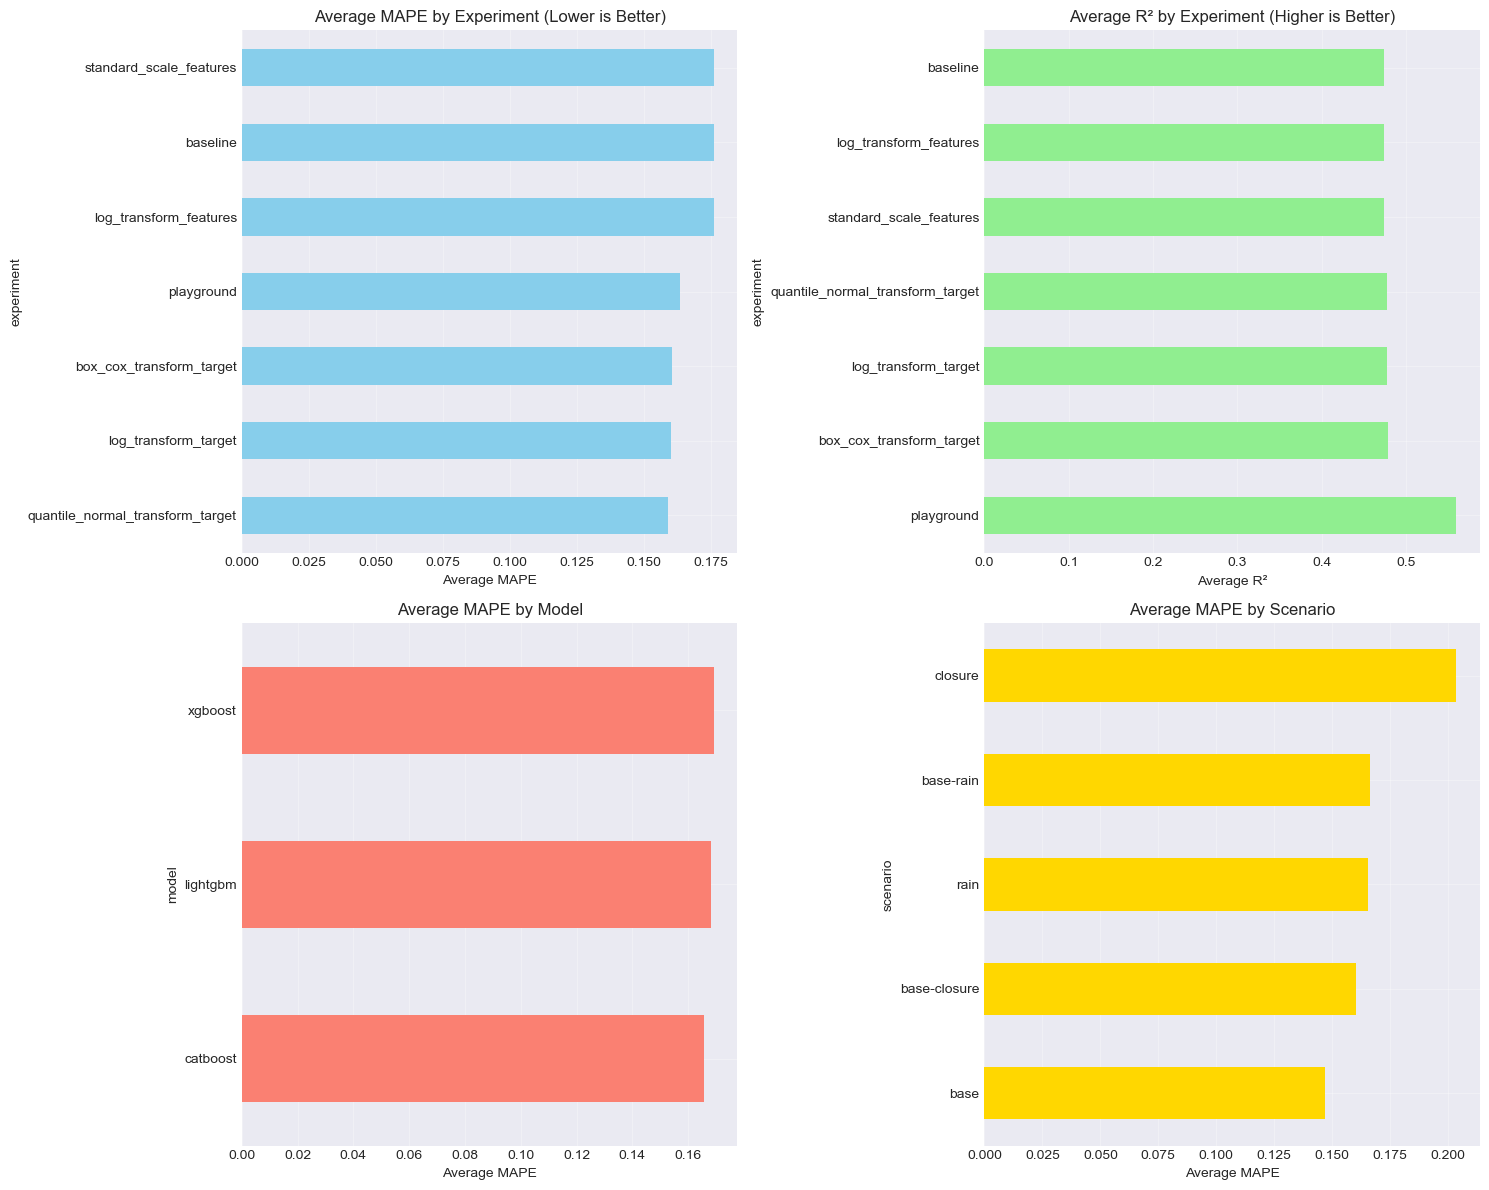

In [9]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. MAPE by Experiment
ax1 = axes[0, 0]
mape_by_exp = df_trees.groupby("experiment")["mape"].mean().sort_values()
mape_by_exp.plot(kind="barh", ax=ax1, color="skyblue")
ax1.set_xlabel("Average MAPE")
ax1.set_title("Average MAPE by Experiment (Lower is Better)")
ax1.grid(True, alpha=0.3)

# 2. R² by Experiment
ax2 = axes[0, 1]
r2_by_exp = df_trees.groupby("experiment")["r2"].mean().sort_values(ascending=False)
r2_by_exp.plot(kind="barh", ax=ax2, color="lightgreen")
ax2.set_xlabel("Average R²")
ax2.set_title("Average R² by Experiment (Higher is Better)")
ax2.grid(True, alpha=0.3)

# 3. MAPE by Model
ax3 = axes[1, 0]
mape_by_model = df_trees.groupby("model")["mape"].mean().sort_values()
mape_by_model.plot(kind="barh", ax=ax3, color="salmon")
ax3.set_xlabel("Average MAPE")
ax3.set_title("Average MAPE by Model")
ax3.grid(True, alpha=0.3)

# 4. MAPE by Scenario
ax4 = axes[1, 1]
mape_by_scenario = df_trees.groupby("scenario")["mape"].mean().sort_values()
mape_by_scenario.plot(kind="barh", ax=ax4, color="gold")
ax4.set_xlabel("Average MAPE")
ax4.set_title("Average MAPE by Scenario")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


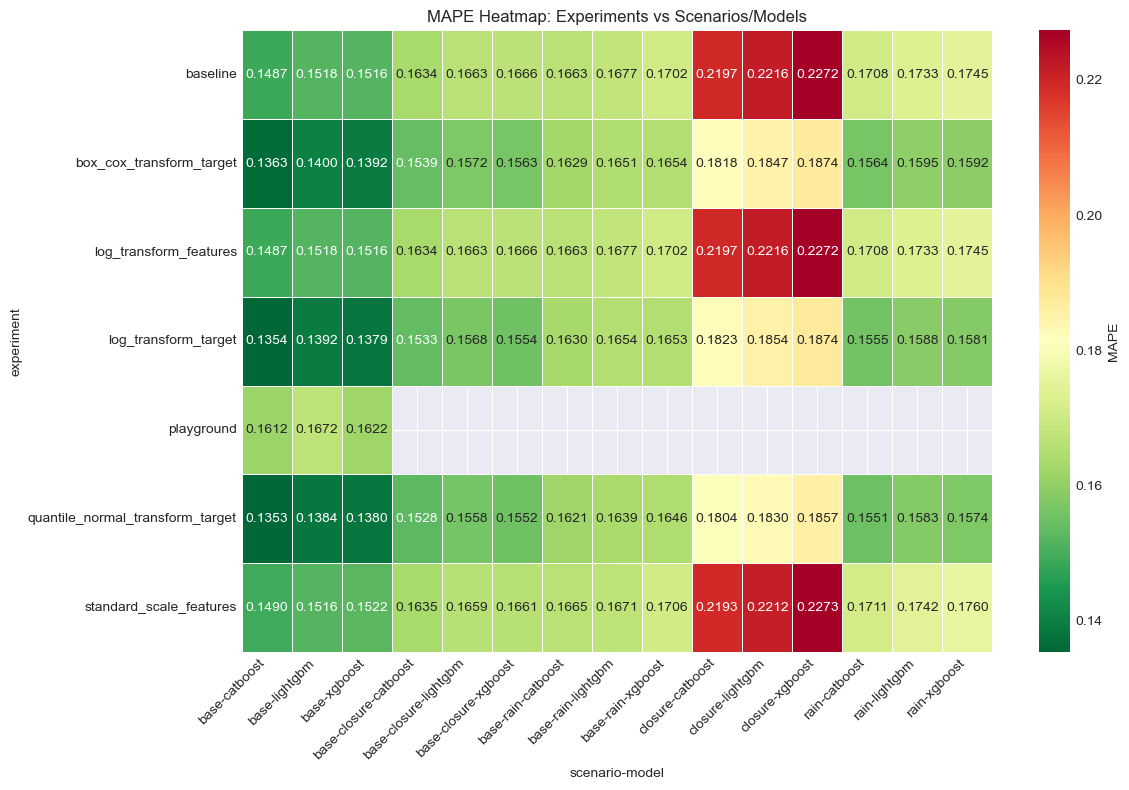

In [10]:
# Create a heatmap of MAPE values
plt.figure(figsize=(12, 8))

# Pivot the data for heatmap
pivot_data = df_trees.pivot_table(values="mape", index="experiment", columns=["scenario", "model"], aggfunc="mean")

# Create heatmap
sns.heatmap(pivot_data, annot=True, fmt=".4f", cmap="RdYlGn_r", cbar_kws={"label": "MAPE"}, linewidths=0.5)
plt.title("MAPE Heatmap: Experiments vs Scenarios/Models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Summary and Insights


In [11]:
# Find the best experiment overall (excluding baseline)
best_experiments = df_trees[df_trees["experiment"] != "baseline"].groupby("experiment")[["mape", "r2"]].mean()
best_experiment = best_experiments["mape"].idxmin()
best_mape = best_experiments.loc[best_experiment, "mape"]
best_r2 = best_experiments.loc[best_experiment, "r2"]

# Calculate baseline averages
baseline_avg = df_trees[df_trees["experiment"] == "baseline"][["mape", "r2"]].mean()

print("SUMMARY OF EXPERIMENTS")
print("=" * 80)
print(f"\nBest Performing Experiment: {best_experiment}")
print(f"  - Average MAPE: {best_mape:.4f} (Baseline: {baseline_avg['mape']:.4f})")
print(f"  - Average R²: {best_r2:.4f} (Baseline: {baseline_avg['r2']:.4f})")
print(f"  - MAPE Improvement: {((baseline_avg['mape'] - best_mape) / baseline_avg['mape'] * 100):.2f}%")
print(f"  - R² Improvement: {((best_r2 - baseline_avg['r2']) / baseline_avg['r2'] * 100):.2f}%")

# Best model overall
best_model_avg = df_trees.groupby("model")[["mape", "r2"]].mean()
best_model = best_model_avg["mape"].idxmin()
print(f"\nBest Performing Model Overall: {best_model}")
print(f"  - Average MAPE: {best_model_avg.loc[best_model, 'mape']:.4f}")
print(f"  - Average R²: {best_model_avg.loc[best_model, 'r2']:.4f}")

# Scenario difficulty ranking
print("\nScenario Difficulty (by average MAPE):")
for scenario in avg_by_scenario.index:
    print(f"  - {scenario}: MAPE = {avg_by_scenario.loc[scenario, 'mape']:.4f}")

# Top 5 best combinations
print("\nTop 5 Best Performing Combinations:")
for idx, row in df_ranking.head(5).iterrows():
    print(
        f"  {int(row['rank_by_mape'])}. {row['experiment']} + {row['model']} + {row['scenario']}: MAPE = {row['mape']:.4f}"
    )


SUMMARY OF EXPERIMENTS

Best Performing Experiment: quantile_normal_transform_target
  - Average MAPE: 0.1591 (Baseline: 0.1760)
  - Average R²: 0.4774 (Baseline: 0.4731)
  - MAPE Improvement: 9.61%
  - R² Improvement: 0.91%

Best Performing Model Overall: catboost
  - Average MAPE: 0.1656
  - Average R²: 0.4824

Scenario Difficulty (by average MAPE):
  - base: MAPE = 0.1470
  - base-closure: MAPE = 0.1603
  - rain: MAPE = 0.1654
  - base-rain: MAPE = 0.1661
  - closure: MAPE = 0.2035

Top 5 Best Performing Combinations:
  1. quantile_normal_transform_target + catboost + base: MAPE = 0.1353
  2. log_transform_target + catboost + base: MAPE = 0.1354
  3. box_cox_transform_target + catboost + base: MAPE = 0.1363
  4. log_transform_target + xgboost + base: MAPE = 0.1379
  5. quantile_normal_transform_target + xgboost + base: MAPE = 0.1380


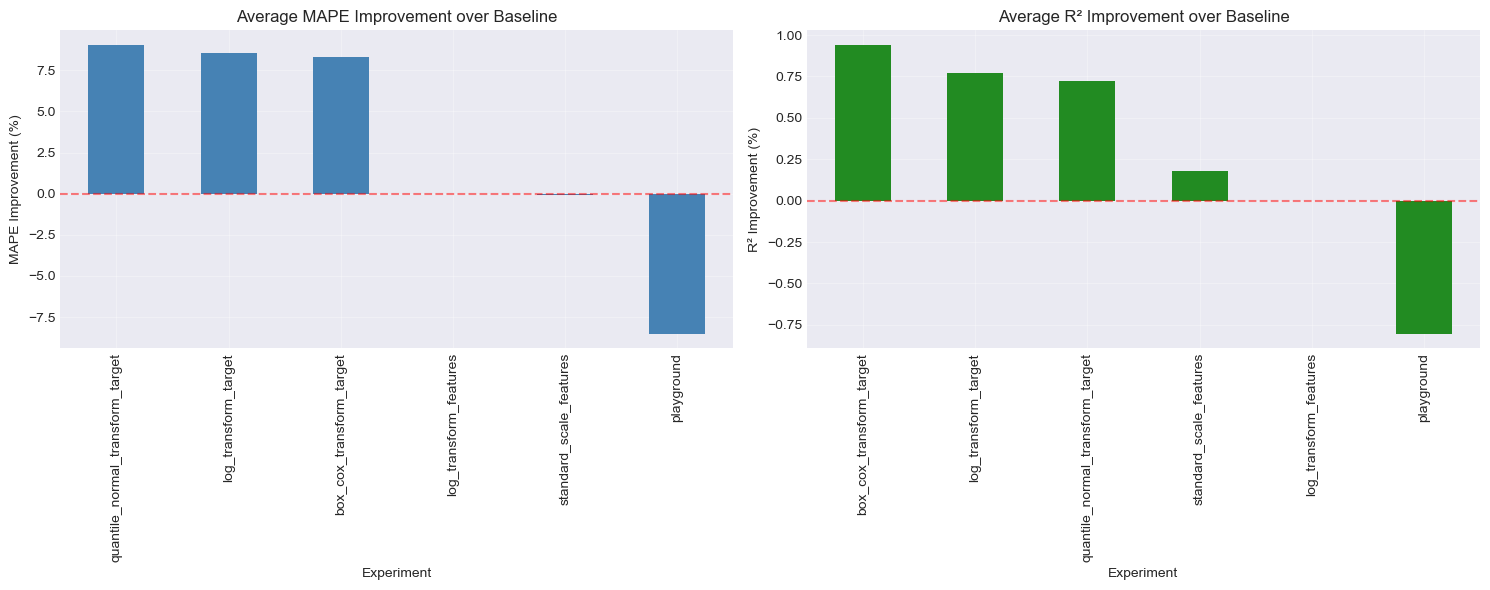

In [12]:
# Create improvement visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Calculate average improvements for each experiment
improvements = (
    df_trees[df_trees["experiment"] != "baseline"].groupby("experiment")[["mape_improvement", "r2_improvement"]].mean()
)

# MAPE Improvement
improvements["mape_improvement"].sort_values(ascending=False).plot(kind="bar", ax=ax1, color="steelblue")
ax1.set_ylabel("MAPE Improvement (%)")
ax1.set_title("Average MAPE Improvement over Baseline")
ax1.axhline(y=0, color="red", linestyle="--", alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel("Experiment")

# R² Improvement
improvements["r2_improvement"].sort_values(ascending=False).plot(kind="bar", ax=ax2, color="forestgreen")
ax2.set_ylabel("R² Improvement (%)")
ax2.set_title("Average R² Improvement over Baseline")
ax2.axhline(y=0, color="red", linestyle="--", alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel("Experiment")

plt.tight_layout()
plt.show()

## Export Results


In [13]:
# Export detailed results to CSV for further analysis
output_file = OUTPUTS_DIR / "experiment_analysis_results.csv"
df_trees.to_csv(output_file, index=False)
print(f"Results exported to: {output_file}")

# Also export the ranking
ranking_file = OUTPUTS_DIR / "experiment_rankings.csv"
df_ranking.to_csv(ranking_file, index=False)
print(f"Rankings exported to: {ranking_file}")

Results exported to: C:\Users\george\Desktop\diploma-thesis\outputs\experiment_analysis_results.csv
Rankings exported to: C:\Users\george\Desktop\diploma-thesis\outputs\experiment_rankings.csv
